# 🧪 TP – Analyse des performances d’étudiants

🎯 **Objectif :** Préparer ce dataset pour un prochain cours qui prédira la note finale d’un étudiant.

### Jeu de données : StudentsPerformance.csv
### Réponder aux questions dans la cellule suivant la question
### Modules autorisés : pandas, mathplotlib, numpy, seaborn, scikit-learn

## 📋 Questions

### 🔹 0. charger le jeu de données et ajout de colonne average_score

a. Charger le jeu de données et puis ajouter une colonne 'average_score' (moyenne des trois notes "math score","reading score","writing score" dans le jeu de données

In [1]:
import pandas as pd

# Charger le jeu de données
df = pd.read_csv('StudentsPerformance.csv')

# Ajouter la colonne 'average_score'
df['average_score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)

# Afficher les premières lignes
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


### 🔹 1. Exploration de base

a. Charger le jeu de données et Afficher les 10 premières lignes du dataset

In [2]:
import pandas as pd

# Charger le jeu de données
df = pd.read_csv('StudentsPerformance.csv')

# Afficher les 10 premières lignes du dataset
df.head(10)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


b. Combien d’étudiants ont participé à l’étude ?

In [3]:
# Le nombre de lignes correspond au nombre d'étudiants ayant participé à l'étude
nb_etudiants = len(df)
print(f"Nombre d'étudiants ayant participé à l'étude : {nb_etudiants}")


Nombre d'étudiants ayant participé à l'étude : 1000


c. Existe-t-il des doublons (étudiants) ?

In [4]:
# Vérification de la présence de lignes en doublons
nb_doublons = df.duplicated().sum()
print(f"Nombre de doublons d'étudiants (lignes identiques) : {nb_doublons}")


Nombre de doublons d'étudiants (lignes identiques) : 0


d. Donner les statistiques de base des scores (max, min, moyenne, mediane)

In [5]:
# Sélection des colonnes de score
score_cols = ['math score', 'reading score', 'writing score']
if 'average_score' in df.columns:
    score_cols.append('average_score')

# Calcul des statistiques de base (min, max, moyenne, médiane)
stats_scores = df[score_cols].agg(['min', 'max', 'mean', 'median'])
stats_scores

,math score,reading score,writing score
min,0.000,17.000,10.000
max,100.000,100.000,100.000
mean,66.089,69.169,68.054
median,66.000,70.000,69.000


### 🔹 2. Détection de valeurs manquantes ou incohérentes

a. Nombre de valeurs manquantes par cellule?

In [6]:
# Somme des valeurs manquantes par colonne
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

b. Combien d'étudiants ont un score moyen < 40 ?

In [7]:
df['average_score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)
# Nombre d'étudiants ayant un score moyen inférieur à 40
nb_low_score = (df['average_score'] < 40).sum()
print(f"Nombre d'étudiants avec un score moyen < 40 : {nb_low_score}")

Nombre d'étudiants avec un score moyen < 40 : 30


c. Valeurs aberrantes pour le score moyen ? (utiliser visualisation et la Méthode de l’écart interquartile [à lire])

In [8]:
# Méthode de l'écart interquartile (IQR) pour la note moyenne
Q1 = df['average_score'].quantile(0.25)
Q3 = df['average_score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Détection des valeurs aberrantes
outliers = df[(df['average_score'] < lower_bound) | (df['average_score'] > upper_bound)]
print(f"Limites pour les valeurs normales : [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Nombre de valeurs aberrantes (IQR) : {len(outliers)}")
if len(outliers) > 0:
    print("\nValeurs aberrantes détectées :")
    print(outliers[['gender', 'average_score']])

Limites pour les valeurs normales : [29.33, 106.67]
Nombre de valeurs aberrantes (IQR) : 6

Valeurs aberrantes détectées :
     gender  average_score
17   female      26.000000
59   female       9.000000
76     male      26.000000
327    male      23.333333
596    male      23.000000
980  female      18.333333


### 🔹 3. Visualisation des données

a. Histogramme des notes moyennes

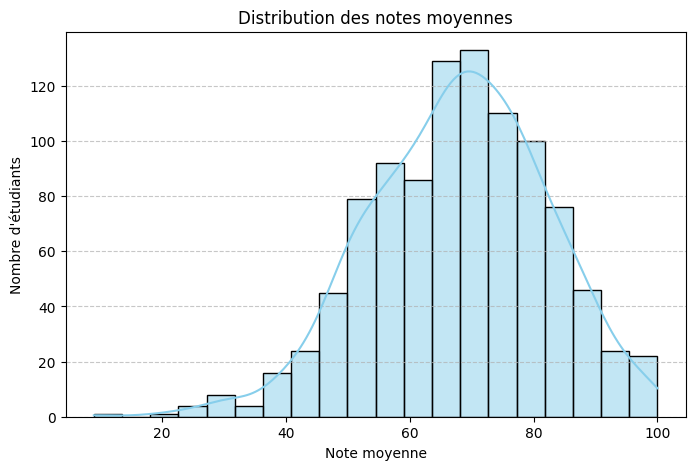

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df['average_score'], kde=True, bins=20, color='skyblue')
plt.title('Distribution des notes moyennes')
plt.xlabel('Note moyenne')
plt.ylabel("Nombre d'étudiants")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

b. Peut-on voir sur cet histogramme des valeurs abérrantes?

In [10]:
# Oui, on peut observer quelques notes très basses sur la queue gauche de la distribution (inférieures à 30),
# qui s'écartent visiblement de la distribution principale (qui ressemble à une loi normale centrée autour de 68).
print("Oui, des valeurs très basses sur la queue gauche s'écartent du comportement général.")

Oui, des valeurs très basses sur la queue gauche s'écartent du comportement général.


c. Faire une boxplot des moyennes par genre.

C:\Users\a.mananjara\AppData\Local\Temp\ipykernel_25432\3768784905.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y='average_score', data=df, palette='Set2')


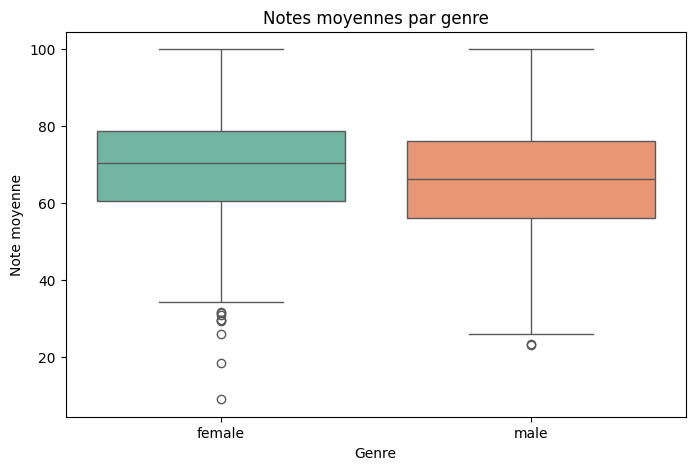

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='gender', y='average_score', data=df, palette='Set2')
plt.title('Notes moyennes par genre')
plt.xlabel('Genre')
plt.ylabel('Note moyenne')
plt.show()

d. Est-ce qu'il y a une différence nette des moyennes de genre sur ce boxplot? 

In [12]:
# Les femmes ('female') ont une médiane et des quartiles légèrement plus élevés que les hommes ('male').
# Il y a donc une différence en leur faveur, mais elle n'est pas extrêmement nette car les deux boîtes
# se chevauchent de manière très importante.
print("Il y a une légère différence en faveur des femmes, mais pas de différence nette ou radicale.")

Il y a une légère différence en faveur des femmes, mais pas de différence nette ou radicale.


e. Barplot moyenne par niveau d'éducation des parents? Peut-on avoir des conclusions sur cette variable?

C:\Users\a.mananjara\AppData\Local\Temp\ipykernel_25432\2649627263.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='average_score', y='parental level of education', data=df, order=order, palette='viridis')


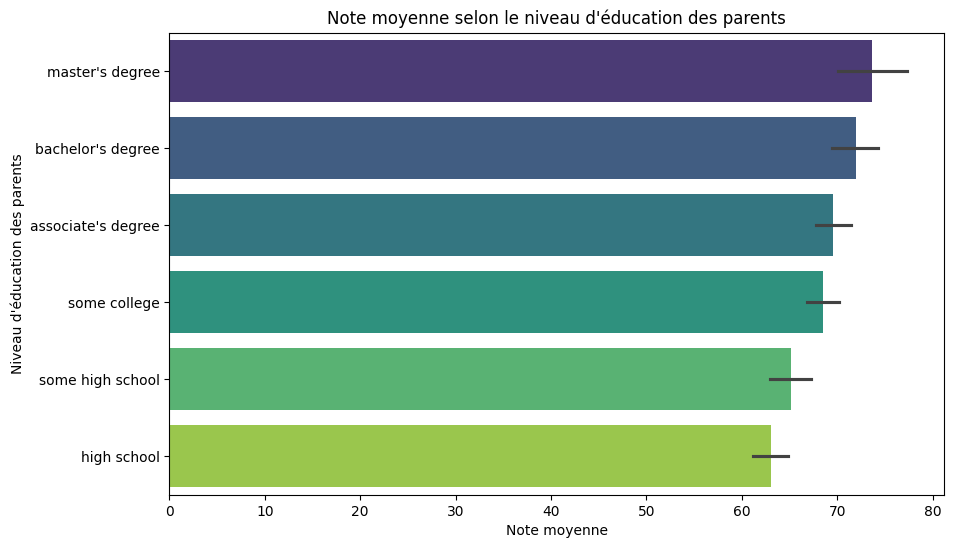

In [13]:
plt.figure(figsize=(10, 6))
order = df.groupby('parental level of education')['average_score'].mean().sort_values(ascending=False).index
sns.barplot(x='average_score', y='parental level of education', data=df, order=order, palette='viridis')
plt.title("Note moyenne selon le niveau d'éducation des parents")
plt.xlabel('Note moyenne')
plt.ylabel("Niveau d'éducation des parents")
plt.show()

# Conclusion : Plus le niveau d'études des parents est élevé (master, bachelor),
# plus les performances moyennes des étudiants ont tendance à être élevées.

d. Faire le Heatmap de corrélation. Quelle est la variable la plus correlée avec la note moyenne?

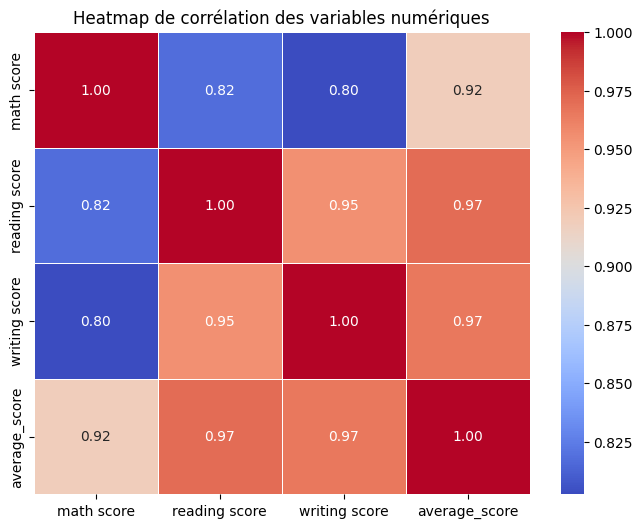

La variable la plus corrélée avec average_score est 'reading score' (0.97)


In [14]:
# Sélection des colonnes numériques pour la corrélation
numeric_cols = df.select_dtypes(include=['number'])
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap de corrélation des variables numériques')
plt.show()

# Détermination de la variable la plus corrélée avec la note moyenne (hors elle-même)
correlations = corr_matrix['average_score'].drop('average_score')
most_correlated = correlations.idxmax()
print(f"La variable la plus corrélée avec average_score est '{most_correlated}' ({correlations.max():.2f})")

### 🔹 4. Nettoyage des données

a. Imputation des NaN (remplacer les NaN par la moyenne de la variable correspondante)

In [15]:
# Imputation des NaN par la moyenne pour le numérique, et le mode pour le catégoriel
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['int64', 'float64']:
            df[col] = df[col].fillna(df[col].mean())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

print("Nombre de valeurs manquantes par colonne après imputation :")
print(df.isnull().sum())

Nombre de valeurs manquantes par colonne après imputation :
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
average_score                  0
dtype: int64


b. Suppression des colonnes inutiles ( Identifiez les colonnes qui sont redondantes, constantes ou sans valeur explicative[aucune corrélation] )

In [16]:
# Pour prédire 'average_score', les scores individuels ('math score', etc.) sont redondants.
# Nous les supprimons pour éviter le leakage d'information.
cols_to_drop = ['math score', 'reading score', 'writing score']
df_cleaned = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
df_cleaned.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,average_score
0,female,group B,bachelor's degree,standard,none,72.666667
1,female,group C,some college,standard,completed,82.333333
2,female,group B,master's degree,standard,none,92.666667
3,male,group A,associate's degree,free/reduced,none,49.333333
4,male,group C,some college,standard,none,76.333333


c. Sélection des colonnes utiles

In [17]:
# Sélection des colonnes explicatives et de la cible
useful_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'average_score']
df_cleaned = df_cleaned[[col for col in useful_cols if col in df_cleaned.columns]]
df_cleaned.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,average_score
0,female,group B,bachelor's degree,standard,none,72.666667
1,female,group C,some college,standard,completed,82.333333
2,female,group B,master's degree,standard,none,92.666667
3,male,group A,associate's degree,free/reduced,none,49.333333
4,male,group C,some college,standard,none,76.333333


### 🔹 5. Encodage

a. Encodage de `gender` ( rendre en numérqieu de façon catégorielle )

In [18]:
# Encodage binaire de gender (female: 0, male: 1)
df_cleaned['gender'] = df_cleaned['gender'].map({'female': 0, 'male': 1})
df_cleaned.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,average_score
0,0,group B,bachelor's degree,standard,none,72.666667
1,0,group C,some college,standard,completed,82.333333
2,0,group B,master's degree,standard,none,92.666667
3,1,group A,associate's degree,free/reduced,none,49.333333
4,1,group C,some college,standard,none,76.333333


b. Encodage one-hot de `parental_level_of_education`

In [19]:
# Encodage One-Hot de la variable d'éducation des parents
df_cleaned = pd.get_dummies(df_cleaned, columns=['parental level of education'], prefix='parent_edu', dtype=int)
df_cleaned.head()

,gender,race/ethnicity,lunch,test preparation course,average_score,parent_edu_associate's degree,parent_edu_bachelor's degree,parent_edu_high school,parent_edu_master's degree,parent_edu_some college,parent_edu_some high school
0,0,group B,standard,none,72.666667,0,1,0,0,0,0
1,0,group C,standard,completed,82.333333,0,0,0,0,1,0
2,0,group B,standard,none,92.666667,0,0,0,1,0,0
3,1,group A,free/reduced,none,49.333333,1,0,0,0,0,0
4,1,group C,standard,none,76.333333,0,0,0,0,1,0


c. Est-il utilise pour l'encodage de `parental_level_of_education` de faire un Regroupement des modalités ? 

In [20]:
# Oui, regrouper les modalités (ex: regrouper les différents diplômes du supérieur) ou utiliser un encodage
# ordinal (puisqu'il y a un ordre hiérarchique) permettrait de réduire le nombre de dimensions créées
# par le One-Hot encoding et de capturer l'ordre des niveaux d'études.
print("Oui, cela permettrait de réduire la dimensionnalité et de mieux modéliser l'ordre des niveaux d'études.")

Oui, cela permettrait de réduire la dimensionnalité et de mieux modéliser l'ordre des niveaux d'études.


### 🔹 6. Préparation finale

a. Créer X (features) et y (cible: average_score)

In [21]:
# Encodage des autres variables catégorielles restantes
cat_cols = ['race/ethnicity', 'lunch', 'test preparation course']
cols_to_encode = [c for c in cat_cols if c in df_cleaned.columns]
df_final = pd.get_dummies(df_cleaned, columns=cols_to_encode, drop_first=True, dtype=int)

# Création de X et y
X = df_final.drop(columns=['average_score'])
y = df_final['average_score']

print(f"Dimensions de X : {X.shape}")
print(f"Dimensions de y : {y.shape}")

Dimensions de X : (1000, 13)
Dimensions de y : (1000,)


b. Vérifier que X est bien numérique

In [22]:
# Vérification que toutes les colonnes de X sont de type numérique
print("Types de X :")
print(X.dtypes)
non_numeric = X.select_dtypes(exclude=['number']).columns
print(f"\nColonnes non numériques restantes : {list(non_numeric)}")

Types de X :
gender                           int64
parent_edu_associate's degree    int64
parent_edu_bachelor's degree     int64
parent_edu_high school           int64
parent_edu_master's degree       int64
parent_edu_some college          int64
parent_edu_some high school      int64
race/ethnicity_group B           int64
race/ethnicity_group C           int64
race/ethnicity_group D           int64
race/ethnicity_group E           int64
lunch_standard                   int64
test preparation course_none     int64
dtype: object

Colonnes non numériques restantes : []


c. Sauvegarder X et y

In [23]:
# Sauvegarde en format CSV
X.to_csv('X_students.csv', index=False)
y.to_csv('y_students.csv', index=False)
print("Fichiers X_students.csv et y_students.csv sauvegardés avec succès.")

Fichiers X_students.csv et y_students.csv sauvegardés avec succès.


## 💡 Bonus

In [24]:
def preprocess_students_data(df_input):
    """
    Fonction de prétraitement complète du jeu de données.
    """
    df_temp = df_input.copy()
    
    # 1. Ajout de average_score si non présent
    if 'average_score' not in df_temp.columns:
        df_temp['average_score'] = df_temp[['math score', 'reading score', 'writing score']].mean(axis=1)
        
    # 2. Imputation des valeurs manquantes
    for col in df_temp.columns:
        if df_temp[col].isnull().sum() > 0:
            if df_temp[col].dtype in ['int64', 'float64']:
                df_temp[col] = df_temp[col].fillna(df_temp[col].mean())
            else:
                df_temp[col] = df_temp[col].fillna(df_temp[col].mode()[0])
                
    # 3. Suppression des colonnes de scores individuels
    cols_to_drop = ['math score', 'reading score', 'writing score']
    df_temp = df_temp.drop(columns=[c for c in cols_to_drop if c in df_temp.columns])
    
    # 4. Encodage de gender
    if 'gender' in df_temp.columns:
        df_temp['gender'] = df_temp['gender'].map({'female': 0, 'male': 1})
        
    # 5. Encodage One-hot des colonnes catégorielles
    categorical_cols = ['parental level of education', 'race/ethnicity', 'lunch', 'test preparation course']
    cols_to_encode = [c for c in categorical_cols if c in df_temp.columns]
    df_temp = pd.get_dummies(df_temp, columns=cols_to_encode, drop_first=True, dtype=int)
    
    # 6. Séparation X et y
    X_out = df_temp.drop(columns=['average_score']) if 'average_score' in df_temp.columns else df_temp
    y_out = df_temp['average_score'] if 'average_score' in df_temp.columns else None
    
    return X_out, y_out

# Test de la fonction de prétraitement
X_test, y_test = preprocess_students_data(df)
print("Test fonction : X =", X_test.shape, ", y =", y_test.shape)

Test fonction : X = (1000, 12) , y = (1000,)


a. Visualisation libre d'une tendance surprenante

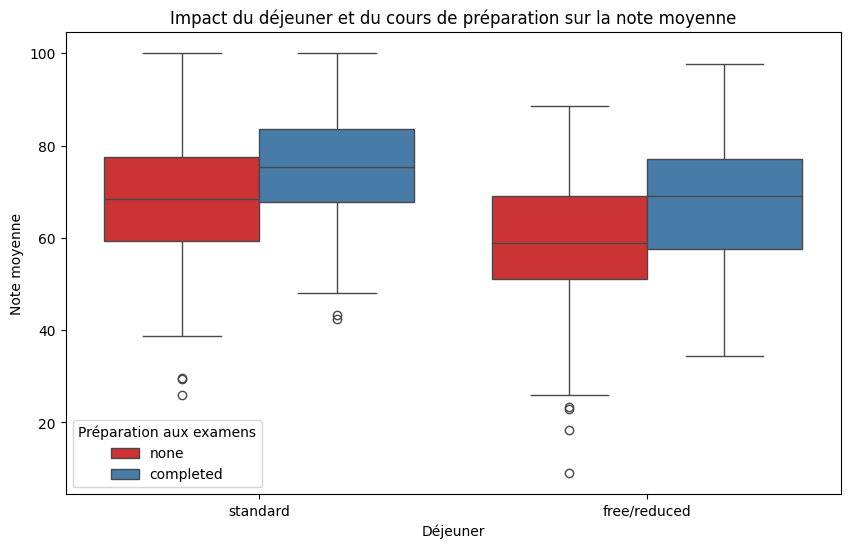

In [25]:
# Impact croisé du type de déjeuner (lunch) et du cours de préparation sur la note moyenne
plt.figure(figsize=(10, 6))
sns.boxplot(x='lunch', y='average_score', hue='test preparation course', data=df, palette='Set1')
plt.title("Impact du déjeuner et du cours de préparation sur la note moyenne")
plt.xlabel('Déjeuner')
plt.ylabel('Note moyenne')
plt.legend(title='Préparation aux examens')
plt.show()

# Observation : Les étudiants avec un déjeuner standard sans cours de préparation s'en sortent en moyenne
# mieux que ceux ayant un déjeuner réduit et ayant suivi le cours de préparation. Cela illustre
# l'influence majeure des facteurs socio-économiques.